# Retail Sales Analytics – Exploratory Data Analysis
---
**Project:** Capstone Data Visualization & Analytics  
**Goal:** Uncover trends, patterns, and insights from the cleaned Superstore retail dataset using visual analytics.

## 1. Setup & Data Loading
Importing visualization libraries and loading the cleaned dataset.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Setting professional visualization style
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

cleaned_file_path = None

# 1. Handle Google Colab Environment
if 'google.colab' in sys.modules:
    print("Detected Google Colab Environment.")
    cleaned_file_path = '/content/cleaned_sales.csv'
    
    if not os.path.exists(cleaned_file_path):
        print("\n--- FILE NOT FOUND ---")
        print("Please upload the 'cleaned_sales.csv' file from your computer.")
        from google.colab import files
        uploaded = files.upload()
        if 'cleaned_sales.csv' not in uploaded and len(uploaded) > 0:
            os.rename(list(uploaded.keys())[0], 'cleaned_sales.csv')

# 2. Handle Local Environment
else:
    potential_paths = [
        'data/processed/cleaned_sales.csv',
        '../data/processed/cleaned_sales.csv',
        './cleaned_sales.csv'
    ]
    for path in potential_paths:
        if os.path.exists(path):
            cleaned_file_path = path
            print(f"Found local file at: {path}")
            break

if cleaned_file_path and os.path.exists(cleaned_file_path):
    df = pd.read_csv(cleaned_file_path)
    # Convert dates back to datetime after CSV loading
    df['Order Date'] = pd.to_datetime(df['Order Date'])
    print(f"\nDataset loaded successfully! Shape: {df.shape}")
else:
    raise FileNotFoundError("Could not locate 'cleaned_sales.csv'. Run 02_cleaning.ipynb first.")

Found local file at: ../data/processed/cleaned_sales.csv

Dataset loaded successfully! Shape: (9994, 24)


## 2. KPI Overview
Summary of core business metrics.

In [5]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
avg_order_value = total_sales / total_orders

print(f"--- Key Performance Indicators ---")
print(f"Total Sales:        ${total_sales:,.2f}")
print(f"Total Profit:       ${total_profit:,.2f}")
print(f"Total Orders:       {total_orders:,}")
print(f"Avg Order Value:    ${avg_order_value:,.2f}")

--- Key Performance Indicators ---
Total Sales:        $2,297,200.86
Total Profit:       $286,397.02
Total Orders:       5,009
Avg Order Value:    $458.61


## 3. Monthly Sales Trend
Visualizing sales performance over time to identify seasonality.

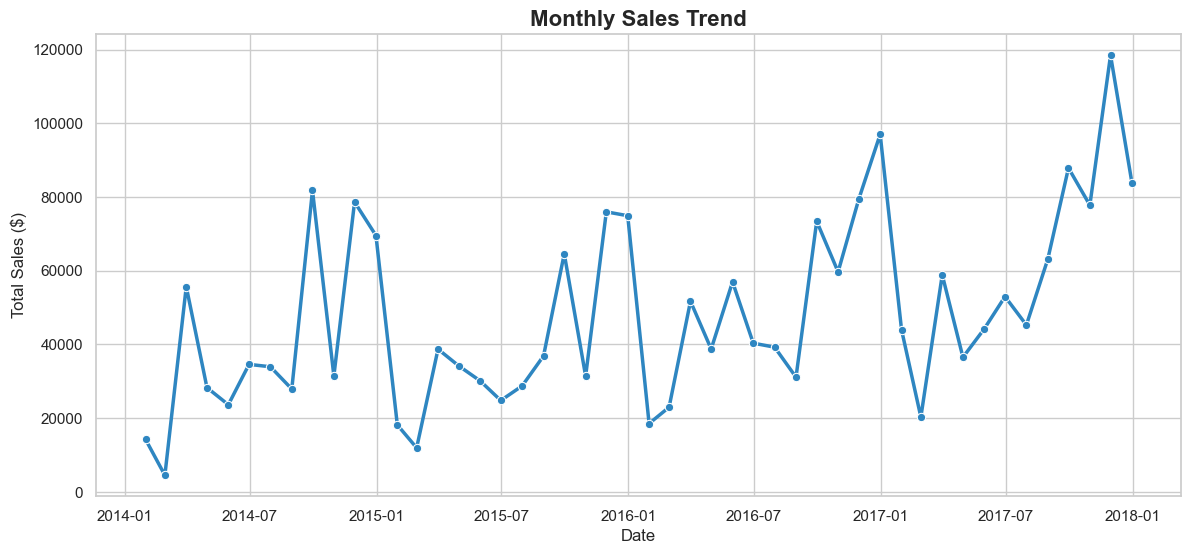

In [6]:
# Note: In pandas 2.2+, 'M' is deprecated for month-end resampling. We use 'ME' instead.
try:
    monthly_sales = df.resample('ME', on='Order Date')['Sales'].sum().reset_index()
except ValueError:
    # Fallback for older pandas versions where 'M' is still used
    monthly_sales = df.resample('M', on='Order Date')['Sales'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x='Order Date', y='Sales', marker='o', color='#2E86C1', linewidth=2.5)
plt.title('Monthly Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.show()

**Insights:**
- Significant growth in sales is observed toward the end of each year (Q4), likely due to holiday shopping seasons.
- There are noticeable dips in early Q1, suggesting a post-holiday cooldown.

## 4. Profit by Region
Evaluating which geographical areas are most lucrative.

/var/folders/44/hf5r20_x4y5bf8kz_wld3rj80000gn/T/ipykernel_46304/3211219282.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_profit, x='Region', y='Profit', palette='magma')


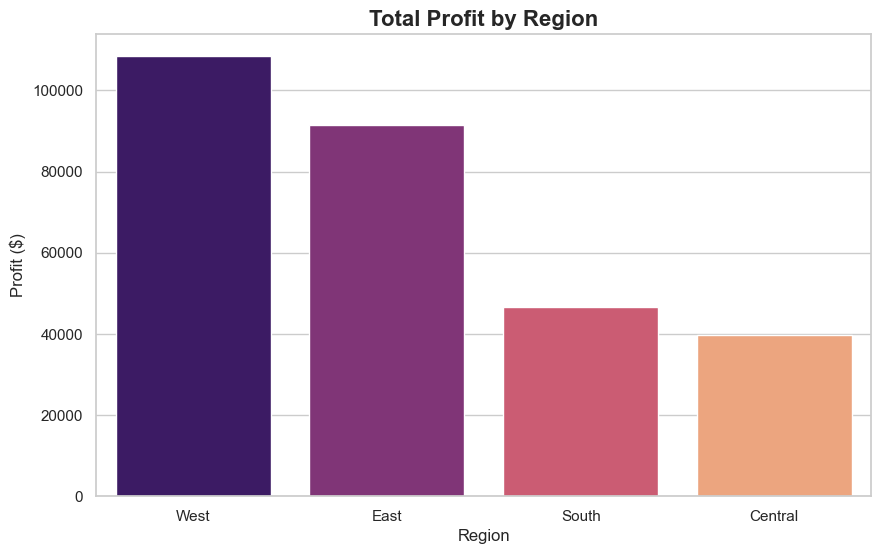

In [7]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=region_profit, x='Region', y='Profit', palette='magma')
plt.title('Total Profit by Region', fontsize=16, fontweight='bold')
plt.ylabel('Profit ($)')
plt.show()

**Insights:**
- The **West** region leads in total profitability, followed by the East.
- The Central region shows the lowest profit levels, which may warrant a review of operational costs or discounting strategies in that area.

## 5. Sales by Category
Analyzing the volume of sales across main product lines.

/var/folders/44/hf5r20_x4y5bf8kz_wld3rj80000gn/T/ipykernel_46304/2205990469.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_sales, x='Category', y='Sales', palette='viridis')


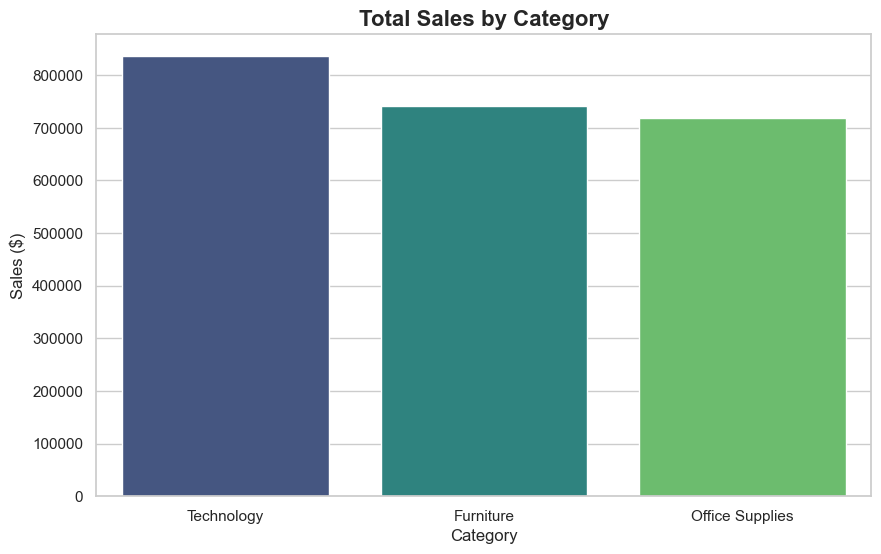

In [8]:
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=cat_sales, x='Category', y='Sales', palette='viridis')
plt.title('Total Sales by Category', fontsize=16, fontweight='bold')
plt.ylabel('Sales ($)')
plt.show()

**Insights:**
- **Technology** and **Furniture** are the primary drivers of revenue.
- Office Supplies has lower total sales but typically higher volume (order count), suggesting it acts as a stable baseline for the business.

## 6. Top 10 Products by Sales
Identifying the best-selling individual items.

/var/folders/44/hf5r20_x4y5bf8kz_wld3rj80000gn/T/ipykernel_46304/2472737672.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, y='Product Name', x='Sales', palette='coolwarm')


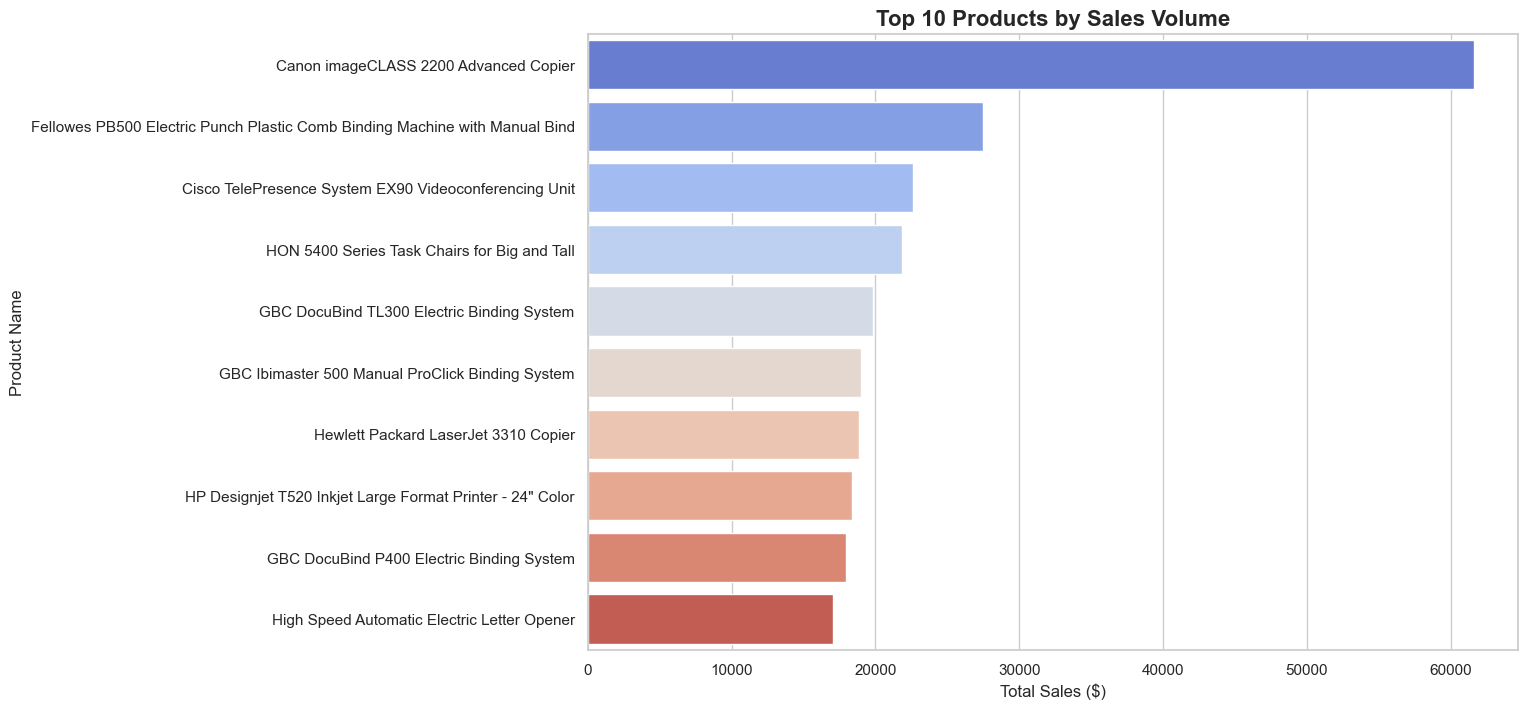

In [9]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(data=top_products, y='Product Name', x='Sales', palette='coolwarm')
plt.title('Top 10 Products by Sales Volume', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.show()

**Insights:**
- High-value items like Copiers and Machines dominate the top list.
- Product-specific marketing should focus on these top performers to maximize ROI.

## 7. Segment-wise Sales
Understanding the customer mix.

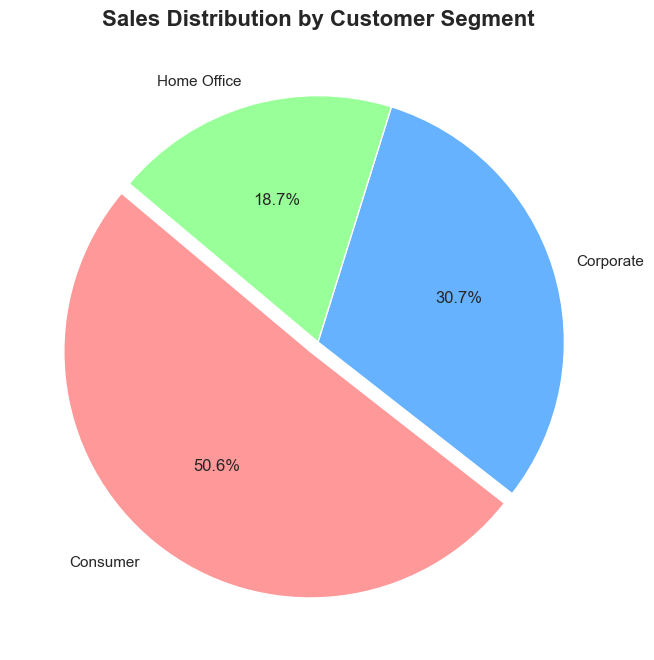

In [10]:
segment_sales = df.groupby('Segment')['Sales'].sum().reset_index()

plt.figure(figsize=(8, 8))
plt.pie(segment_sales['Sales'], labels=segment_sales['Segment'], autopct='%1.1f%%', 
        startangle=140, colors=['#FF9999', '#66B2FF', '#99FF99'], explode=(0.05, 0, 0))
plt.title('Sales Distribution by Customer Segment', fontsize=16, fontweight='bold')
plt.show()

**Insights:**
- The **Consumer** segment accounts for over 50% of total sales, making it the most critical demographic.
- Corporate and Home Office segments provide significant secondary revenue streams.

## 8. Discount vs Profit
Investigating the impact of aggressive pricing on the bottom line.

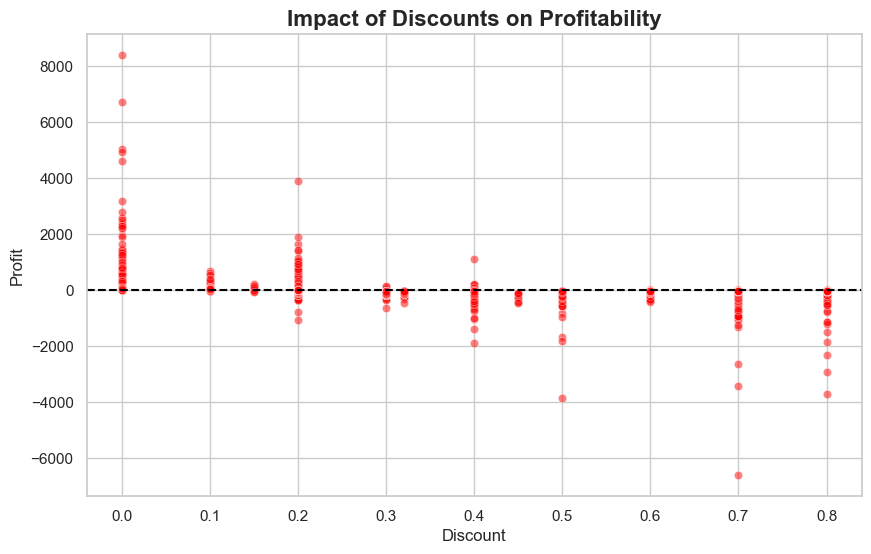

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5, color='red')
plt.title('Impact of Discounts on Profitability', fontsize=16, fontweight='bold')
plt.axhline(0, color='black', linestyle='--')
plt.show()

**Insights:**
- Higher discounts (above 20-30%) are strongly correlated with negative profits.
- Strategic discounting is necessary to clear inventory without eroding the total margin.

## 9. Heatmap Correlation Matrix
Analyzing relationships between numeric variables.

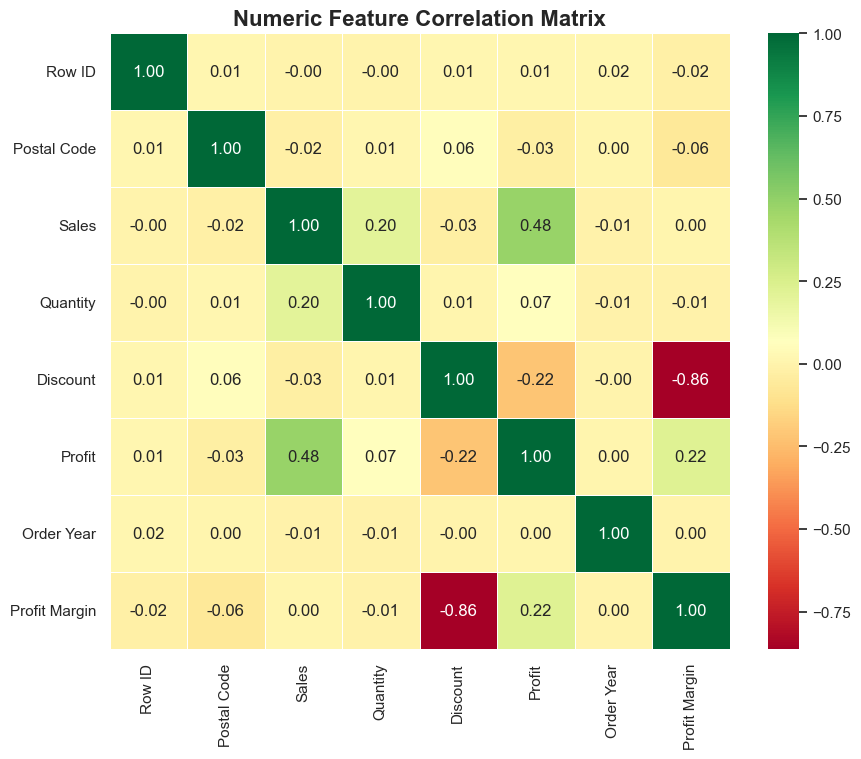

In [12]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Numeric Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.show()

**Insights:**
- **Sales** and **Profit** show a moderate positive correlation, as expected.
- **Discount** has a negative correlation with **Profit**, confirming the trend seen in the scatter plot.
- **Quantity** has a weak correlation with profit, suggesting that simply selling more units doesn't guarantee higher margins if the unit profit is low.

## Conclusion
The EDA phase has revealed that while the West region and Technology category are performing exceptionally well, aggressive discounting is a major risk factor for profitability. Future strategies should focus on the Consumer segment while optimizing discount thresholds to ensure sustainable growth.